# Semana 01 · Ciclo de vida completo de un modelo con MLflow

En esta práctica llevarás un caso de clasificación desde los datos hasta una API local:

`datos → experimentos → comparación → gate → modelo ganador → Registry → API → observabilidad`

El objetivo no es conseguir el número más alto, sino construir una decisión **reproducible,
auditable y desplegable**. El dataset cardiovascular es únicamente didáctico: el resultado
no puede usarse para diagnóstico, tratamiento ni decisiones sobre pacientes.

**Entorno:** Databricks Free Edition, compute serverless y experimento asociado a este notebook.
No necesitas tarjeta de crédito, cluster propio, Docker, `uv`, `pyproject.toml` ni tokens.

## Mapa y criterios de terminación

Al acabar debes poder enseñar en MLflow:

1. un lote de al menos seis runs comparables, con datos, parámetros, métricas y artefactos;
2. una regla de selección escrita **antes** de mirar el test;
3. un único candidato evaluado sobre test y marcado como ganador;
4. versiones en Unity Catalog y un ciclo `Challenger → Champion → rollback`;
5. una API HTTP local que carga el `model.pkl` del run ganador y supera pruebas válidas e inválidas;
6. un run de despliegue con latencia, volumen de peticiones, errores y evidencia de la respuesta.

Tiempo recomendado: 45 min de construcción guiada + 120–180 min de práctica autónoma y debrief.

## 0. Dependencias

Ejecuta `%pip` al principio. Si Databricks reinicia Python, continúa desde la celda de imports.
Las dependencias se instalan en la sesión del notebook; no se crea ningún entorno o fichero de
proyecto en el repositorio.

In [0]:
%pip install -q --upgrade "mlflow[databricks]==3.14.0" "scikit-learn==1.9.0" "pandas==2.2.3" "matplotlib==3.11.1"

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## Cómo trabajar con la versión sin resolver

Ejecuta las celdas en orden y completa cada `TODO`. Los bloques se detienen con
`NotImplementedError` para que un fallo no genere evidencia engañosa. Consulta la guía del
alumno antes de mirar la solución. Mantén el test cerrado hasta haber elegido el ganador.

## 1. Configuración e identidad del lote

In [0]:
import json
import pickle
import re
import tempfile
import threading
import time
import uuid
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
from pathlib import Path
from urllib.error import HTTPError
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import sklearn
from mlflow import MlflowClient
from mlflow.models import infer_signature
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

STUDENT_ALIAS = "ac-s01"
BATCH_ID = uuid.uuid4().hex[:8]
RANDOM_STATE = 42
MIN_VALIDATION_RECALL = 0.72
DATASET_PATH = "../../../data/raw/heart.csv"

# TODO 1: valido el alias (3-24 caracteres, minusculas, numeros o guiones, nada de correos)
assert re.fullmatch(r"[a-z0-9-]{3,24}", STUDENT_ALIAS), "Alias no valido"
assert not STUDENT_ALIAS.startswith("todo"), "Cambia el alias de ejemplo"

# tracking de Databricks: los runs van al experimento de este notebook
mlflow.set_tracking_uri("databricks")
ARTIFACT_DIR = Path(tempfile.mkdtemp())  
print({"alias": STUDENT_ALIAS, "batch_id": BATCH_ID})

{'alias': 'ac-s01', 'batch_id': '7a7a1fe0'}


## 2. Contrato y controles de datos

Permite nulos porque el pipeline los imputará, pero detente si faltan columnas, el dataset está
vacío o el target no es binario. Construye un `quality_report` serializable como JSON.

In [0]:
data = pd.read_csv(DATASET_PATH)
TARGET = "target"
EXPECTED_FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal",
]

# TODO 2: contrato minimo
missing_columns = sorted(set(EXPECTED_FEATURES + [TARGET]) - set(data.columns))
assert not missing_columns, f"Faltan columnas: {missing_columns}"
assert len(data) > 0, "El dataset esta vacio"
assert set(data[TARGET].unique()) == {0, 1}, "El target tiene que ser binario"

X = data[EXPECTED_FEATURES]
y = data[TARGET]

# los nulos no paran el notebook porque el pipeline los imputa, pero los apunto
quality_report = {
    "rows": int(len(data)),
    "duplicated_rows": int(data.duplicated().sum()),
    "target_distribution": {str(k): int(v) for k, v in y.value_counts().sort_index().items()},
    "null_values": {col: int(n) for col, n in X.isna().sum().items() if n > 0},
    "checks": ["columnas obligatorias", "dataset no vacio", "target binario", "nulos permitidos"],
}
print(json.dumps(quality_report, indent=2))

{
  "rows": 303,
  "duplicated_rows": 1,
  "target_distribution": {
    "0": 138,
    "1": 165
  },
  "null_values": {
    "trestbps": 45,
    "chol": 30
  },
  "checks": [
    "columnas obligatorias",
    "dataset no vacio",
    "target binario",
    "nulos permitidos"
  ]
}


## 3. Divide 60 % train, 20 % validación y 20 % test, siempre estratificado

In [0]:
# TODO 3: primero separo test (20 %) y del resto saco validacion (25 % de 80 % = 20 %)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_full
)

assert len(X_train) + len(X_valid) + len(X_test) == len(data)
print({"train": len(X_train), "valid": len(X_valid), "test": len(X_test)})
print("proporcion de 1 -> train:", round(y_train.mean(), 2), "valid:", round(y_valid.mean(), 2),
      "test:", round(y_test.mean(), 2))

{'train': 181, 'valid': 61, 'test': 61}
proporcion de 1 -> train: 0.55 valid: 0.54 test: 0.54


## 4. Pipeline y funciones de evaluación

In [0]:
# todo lo que no es numerico (texto y bool) lo trato como categorico
categorical_columns = X.select_dtypes(exclude="number").columns.tolist()
numeric_columns = [c for c in EXPECTED_FEATURES if c not in categorical_columns]
print("categoricas:", categorical_columns)
print("numericas:", numeric_columns)


def build_pipeline(config: dict) -> Pipeline:
    # TODO 4a: imputacion + one hot en el mismo pipeline que el modelo
    numeric = SimpleImputer(strategy="median")
    categorical = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocess = ColumnTransformer([
        ("num", numeric, numeric_columns),
        ("cat", categorical, categorical_columns),
    ])
    return Pipeline([("preprocess", preprocess), ("model", RandomForestClassifier(**config))])


def evaluate_classifier(model: Pipeline, features: pd.DataFrame, labels: pd.Series) -> dict:
    # TODO 4b: metricas + latencia por fila
    start = time.perf_counter()
    predictions = model.predict(features)
    latency_ms_per_row = (time.perf_counter() - start) * 1000 / len(features)
    probabilities = model.predict_proba(features)[:, 1]
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions),
        "f1": f1_score(labels, predictions),
        "roc_auc": roc_auc_score(labels, probabilities),
        "latency_ms_per_row": latency_ms_per_row,
    }


categoricas: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
numericas: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']


## 5. Diseña al menos seis candidatos comparables

In [0]:
# TODO 5: el primero es la base y en los demas cambio uno o dos parametros
CANDIDATES = [
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1, "class_weight": None, "random_state": RANDOM_STATE},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1, "class_weight": None, "random_state": RANDOM_STATE},
    {"n_estimators": 100, "max_depth": 4, "min_samples_leaf": 1, "class_weight": None, "random_state": RANDOM_STATE},
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 5, "class_weight": None, "random_state": RANDOM_STATE},
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1, "class_weight": "balanced", "random_state": RANDOM_STATE},
    {"n_estimators": 300, "max_depth": 6, "min_samples_leaf": 3, "class_weight": "balanced", "random_state": RANDOM_STATE},
]
assert len(CANDIDATES) >= 6, "Necesitas al menos seis candidatos."
assert all("random_state" in c for c in CANDIDATES)

## 6. Tracking profundo: un run por candidato

Por cada candidato registra tags, parámetros, versiones, inputs de train/validación, tarjeta de
datos, calidad, riesgos, métricas, reporte por clase, matriz de confusión, modelo MLflow con
firma/input example, `deployment/model.pkl` y contrato de inferencia.

In [0]:
dataset_card = {
    "source": "data/raw/heart.csv (copia docente del repositorio)",
    "purpose": "Practicar tracking, seleccion y despliegue de un clasificador binario. Solo docente.",
    "features": EXPECTED_FEATURES,
    "target": TARGET,
    "split": {"train": 0.60, "validation": 0.20, "test": 0.20, "random_state": RANDOM_STATE},
    "known_limitations": [
        "Solo 303 filas: las metricas cambian bastante con el split",
        "Hay nulos en trestbps y chol que se imputan con la mediana",
        "No sabemos como se recogieron los datos ni si representan a la poblacion",
    ],
}
risk_register = {
    "version": "s01-lifecycle",
    "risks": [
        {"id": "R1", "risk": "Usar la prediccion para diagnosticar o decidir sobre un paciente", "impact": "high",
         "owner": "responsable del producto", "mitigation": "Aviso de uso docente y la API solo en localhost"},
        {"id": "R2", "risk": "Que acabe un token o dato personal en params, tags o artefactos", "impact": "high",
         "owner": "responsable tecnico", "mitigation": "Alias anonimo, sin credenciales en el notebook y no guardar payloads"},
        {"id": "R3", "risk": "Training y serving con preprocesado distinto", "impact": "high",
         "owner": "ml engineer", "mitigation": "Preprocesado dentro del Pipeline y pruebas de contrato en la API"},
        {"id": "R4", "risk": "Demasiados falsos negativos (enfermos que el modelo no detecta)", "impact": "high",
         "owner": "responsable del modelo", "mitigation": "Gate de recall minimo en validacion antes de elegir"},
    ],
}
assert len(dataset_card["known_limitations"]) >= 3
assert len(risk_register["risks"]) >= 4

### 6a. Inputs de datos

Crea dos objetos `mlflow.data` con nombres distintos. Comprueba sus nombres antes de lanzar runs.

In [0]:
# TODO 6a
train_dataset = mlflow.data.from_pandas(
    X_train.assign(target=y_train), source=DATASET_PATH, targets="target", name="heart_train"
)
validation_dataset = mlflow.data.from_pandas(
    X_valid.assign(target=y_valid), source=DATASET_PATH, targets="target", name="heart_validation"
)
print(train_dataset.name, validation_dataset.name)
assert train_dataset.name != validation_dataset.name

heart_train heart_validation


/local_disk0/.ephemeral_nfs/envs/pythonEnv-e8c69467-0af6-43c1-93ed-875b257299c3/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-e8c69467-0af6-43c1-93ed-875b257299c3/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


### 6b. Artefactos del candidato

Implementa una función pequeña que registre firma/input example, `model_info.model_uri`, pickle,
tamaño, matriz de confusión y contrato. Podrás probarla dentro de un único run antes del bucle.

In [0]:
def log_candidate_artifacts(
    model: Pipeline, predictions: np.ndarray, candidate_index: int
) -> str:
    # TODO 6b
    # modelo MLflow con firma e input example
    signature = infer_signature(X_train, model.predict(X_train))
    # con skops (el formato por defecto en mlflow nuevo) los arboles dan error, uso cloudpickle
    model_info = mlflow.sklearn.log_model(
        model, name="model", signature=signature, input_example=X_train.head(3),
        serialization_format="cloudpickle",
    )
    mlflow.set_tag("candidate.model_uri", model_info.model_uri)

    # pickle para la API
    pickle_path = ARTIFACT_DIR / "model.pkl"
    with open(pickle_path, "wb") as f:
        pickle.dump(model, f)
    mlflow.log_artifact(str(pickle_path), artifact_path="deployment")
    mlflow.log_metric("pickle_size_bytes", pickle_path.stat().st_size)

    # matriz de confusion en validacion
    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay.from_predictions(y_valid, predictions, ax=ax)
    ax.set_title(f"Candidato {candidate_index}")
    mlflow.log_figure(fig, "validation/confusion_matrix.png")
    plt.close(fig)

    # contrato de inferencia
    inference_contract = {
        "request": {"instances": "lista no vacia de objetos con todas y solo estas columnas"},
        "features": EXPECTED_FEATURES,
        "response": {"predictions": "0 o 1", "probabilities": "probabilidad de la clase 1"},
        "errors": "400 si el json no es un objeto, falta o sobra alguna columna",
        "uso": "solo docente, no sirve para diagnostico",
    }
    mlflow.log_dict(inference_contract, "deployment/inference_contract.json")
    return model_info.model_uri

### 6c. Runs comparables

Ahora el bucle se ocupa sólo de identidad, parámetros, inputs, gobierno, entrenamiento, métricas
y de llamar al helper de artefactos. Conserva `experiment_id` y cada `run_id`.

In [0]:
experiment_id = None
candidate_run_ids = []

# TODO 6c
for i, config in enumerate(CANDIDATES, start=1):
    with mlflow.start_run(run_name=f"{STUDENT_ALIAS}-{BATCH_ID}-candidato-{i:02d}") as run:
        experiment_id = run.info.experiment_id
        # identidad
        mlflow.set_tags({
            "student.alias": STUDENT_ALIAS,
            "batch.id": BATCH_ID,
            "lifecycle.phase": "candidate",
            "use_case": "clasificacion cardiovascular docente",
            "risk.level": "high",
            "candidate.index": i,
        })
        # parametros y versiones
        mlflow.log_params(config)
        mlflow.log_params({
            "train_rows": len(X_train),
            "validation_rows": len(X_valid),
            "test_rows": len(X_test),
            "sklearn_version": sklearn.__version__,
            "mlflow_version": mlflow.__version__,
            "pandas_version": pd.__version__,
        })
        # datos y gobierno
        mlflow.log_input(train_dataset, context="training")
        mlflow.log_input(validation_dataset, context="validation")
        mlflow.log_dict(dataset_card, "data/dataset_card.json")
        mlflow.log_dict(quality_report, "data/quality_report.json")
        mlflow.log_dict(risk_register, "governance/risk_register.json")

        # entreno y evaluo en validacion
        model = build_pipeline(config)
        start = time.perf_counter()
        model.fit(X_train, y_train)
        mlflow.log_metric("fit_time_s", time.perf_counter() - start)

        metrics = evaluate_classifier(model, X_valid, y_valid)
        mlflow.log_metrics({f"validation.{k}": v for k, v in metrics.items()})

        valid_pred = model.predict(X_valid)
        report = classification_report(y_valid, valid_pred, output_dict=True, zero_division=0)
        mlflow.log_dict(report, "validation/classification_report.json")

        log_candidate_artifacts(model, valid_pred, i)
        candidate_run_ids.append(run.info.run_id)
        print(f"candidato {i}: recall={metrics['recall']:.3f} f1={metrics['f1']:.3f} roc_auc={metrics['roc_auc']:.3f}")

assert len(candidate_run_ids) == len(CANDIDATES)

2026/10/04 18:46:49 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
/local_disk0/.ephemeral_nfs/envs/pythonEnv-e8c69467-0af6-43c1-93ed-875b257299c3/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ 

candidato 1: recall=0.818 f1=0.818 roc_auc=0.881


2026/10/04 18:47:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
/local_disk0/.ephemeral_nfs/envs/pythonEnv-e8c69467-0af6-43c1-93ed-875b257299c3/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ 

candidato 2: recall=0.848 f1=0.836 roc_auc=0.872


/local_disk0/.ephemeral_nfs/envs/pythonEnv-e8c69467-0af6-43c1-93ed-875b257299c3/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/04 18:47:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it 

...

candidato 4: recall=0.848 f1=0.836 roc_auc=0.868


/local_disk0/.ephemeral_nfs/envs/pythonEnv-e8c69467-0af6-43c1-93ed-875b257299c3/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/04 18:47:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it 

candidato 5: recall=0.848 f1=0.812 roc_auc=0.859


/local_disk0/.ephemeral_nfs/envs/pythonEnv-e8c69467-0af6-43c1-93ed-875b257299c3/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/04 18:47:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it 

candidato 6: recall=0.788 f1=0.800 roc_auc=0.866


## 7. Busca y compara exclusivamente los runs de tu alias y `BATCH_ID`

In [0]:
# TODO 7
filter_string = (
    f"tags.student.alias = '{STUDENT_ALIAS}' and tags.batch.id = '{BATCH_ID}' "
    "and tags.lifecycle.phase = 'candidate'"
)
runs = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=filter_string)

columns = [
    "run_id", "tags.candidate.index",
    "params.n_estimators", "params.max_depth", "params.min_samples_leaf", "params.class_weight",
    "metrics.validation.recall", "metrics.validation.f1", "metrics.validation.roc_auc",
    "metrics.validation.accuracy", "metrics.validation.latency_ms_per_row", "tags.candidate.model_uri",
]
comparison = runs[columns].sort_values("tags.candidate.index").reset_index(drop=True)
display(comparison)
assert len(comparison) == len(CANDIDATES)
assert set(runs["tags.batch.id"]) == {BATCH_ID}

run_id,tags.candidate.index,params.n_estimators,params.max_depth,params.min_samples_leaf,params.class_weight,metrics.validation.recall,metrics.validation.f1,metrics.validation.roc_auc,metrics.validation.accuracy,metrics.validation.latency_ms_per_row,tags.candidate.model_uri
46cd70e6ab4f4cd08046908528e6cfc9,1,100,None,1,None,0.8181818181818182,0.8181818181818182,0.880952380952381,0.8032786885245902,0.1947145245877869,models:/m-be524bafe1704fc38b973539b9dc0e1f
53ebaf82b76c4668a05d52b4e5cba489,2,300,None,1,None,0.8484848484848485,0.835820895522388,0.8722943722943725,0.819672131147541,0.38225936065351024,models:/m-a527c4225ba74105ad3a5221607c44db
53f8b2e03abe41bd87e3ad7cfcecf1a7,3,100,4,1,None,0.8787878787878788,0.8285714285714286,0.8647186147186148,0.8032786885245902,0.18804470491737507,models:/m-0c0956459ed14368a4faecbc9e5668b3
a1819cee30b44509a39158b1bb8b9862,4,100,None,5,None,0.8484848484848485,0.835820895522388,0.867965367965368,0.819672131147541,0.2766172950844923,models:/m-0d0965f5599649dc8fd0fb8890648d3d
df503c0af70149caaac5c732dc4ee263,5,100,None,1,balanced,0.8484848484848485,0.8115942028985508,0.8593073593073594,0.7868852459016393,0.1940152950827142,models:/m-dfb197e8f0c94bb38154ae02ec7b01eb
aaaaeb25d32d446f879cbeb843e24819,6,300,6,3,balanced,0.7878787878787878,0.8,0.8658008658008658,0.7868852459016393,0.3985185081979043,models:/m-7a38f06aecb7488ca21ccff662f943bc


## 8. Aplica el gate sin mirar test

Filtra por recall mínimo; ordena por F1 DESC, ROC AUC DESC y latencia ASC. Conserva
`BEST_RUN_ID`, `BEST_MODEL_URI` y un `selection_report` que diga explícitamente que test no
participó en la selección.

In [0]:
# TODO 8: primero el gate de recall y luego F1, ROC AUC y latencia
eligible = comparison[comparison["metrics.validation.recall"] >= MIN_VALIDATION_RECALL]
assert not eligible.empty, "Ningun candidato llega al recall minimo. No bajo el umbral, hay que revisar los candidatos."

ranked = eligible.sort_values(
    ["metrics.validation.f1", "metrics.validation.roc_auc", "metrics.validation.latency_ms_per_row"],
    ascending=[False, False, True],
)
best = ranked.iloc[0]
BEST_RUN_ID = best["run_id"]
BEST_MODEL_URI = best["tags.candidate.model_uri"]

selection_report = {
    "gate": f"validation.recall >= {MIN_VALIDATION_RECALL}",
    "ranking": ["validation.f1 DESC", "validation.roc_auc DESC", "validation.latency_ms_per_row ASC"],
    "candidates": len(comparison),
    "eligible": len(eligible),
    "rejected_run_ids": comparison.loc[~comparison["run_id"].isin(eligible["run_id"]), "run_id"].tolist(),
    "best_run_id": BEST_RUN_ID,
    "best_candidate_index": best["tags.candidate.index"],
    "best_model_uri": BEST_MODEL_URI,
    "test_used_for_selection": False,
}
print(json.dumps(selection_report, indent=2))

{
  "gate": "validation.recall >= 0.72",
  "ranking": [
    "validation.f1 DESC",
    "validation.roc_auc DESC",
    "validation.latency_ms_per_row ASC"
  ],
  "candidates": 6,
  "eligible": 6,
  "rejected_run_ids": [],
  "best_run_id": "53ebaf82b76c4668a05d52b4e5cba489",
  "best_candidate_index": "2",
  "best_model_uri": "models:/m-a527c4225ba74105ad3a5221607c44db",
  "test_used_for_selection": false
}


## 9. Carga el modelo desde MLflow, evalúa test una sola vez y completa el run ganador

In [0]:
# TODO 9: cargo el modelo guardado (no el de memoria) y abro test una sola vez
best_model = mlflow.sklearn.load_model(BEST_MODEL_URI)
test_metrics = evaluate_classifier(best_model, X_test, y_test)
test_dataset = mlflow.data.from_pandas(
    X_test.assign(target=y_test), source=DATASET_PATH, targets="target", name="heart_test"
)

with mlflow.start_run(run_id=BEST_RUN_ID):
    mlflow.log_input(test_dataset, context="testing")
    mlflow.log_metrics({f"test.{k}": v for k, v in test_metrics.items()})
    mlflow.set_tags({"selection.status": "winner", "selection.rule": selection_report["gate"]})
    mlflow.log_dict({**selection_report, "test_metrics": test_metrics}, "selection/decision.json")

assert "test.recall" in mlflow.get_run(BEST_RUN_ID).data.metrics
print({k: round(v, 3) for k, v in test_metrics.items()})

/local_disk0/.ephemeral_nfs/envs/pythonEnv-e8c69467-0af6-43c1-93ed-875b257299c3/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-e8c69467-0af6-43c1-93ed-875b257299c3/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (flo

{'accuracy': 0.77, 'precision': 0.757, 'recall': 0.848, 'f1': 0.8, 'roc_auc': 0.885, 'latency_ms_per_row': 0.468}


## 10. Registra el modelo ganador en Unity Catalog

Usa el catálogo y esquema activos, un nombre de tres niveles y tu alias saneado. Añade
descripción y tags. Registra referencia+ganador, asigna `Challenger`, haz smoke test,
promociona, comprueba rollback y deja el ganador como `Champion`. Si recibes `PERMISSION_DENIED`, consulta la
guía: no pegues credenciales ni cambies a recursos de pago.

In [0]:
# TODO 10: registry de Unity Catalog, nombre catalogo.esquema.modelo
mlflow.set_registry_uri("databricks-uc")
client = MlflowClient(registry_uri="databricks-uc")
catalog_name, schema_name = spark.sql("SELECT current_catalog(), current_schema()").first()
safe_alias = re.sub(r"[^a-z0-9_]", "_", STUDENT_ALIAS.lower())
REGISTERED_MODEL_NAME = f"{catalog_name}.{schema_name}.heart_disease_classifier_{safe_alias}"
print("modelo:", REGISTERED_MODEL_NAME)

# referencia para el rollback, segundo del ranking (si solo hay uno)
reference_row = ranked.iloc[1] if len(ranked) > 1 else ranked.iloc[0]
reference_version = mlflow.register_model(reference_row["tags.candidate.model_uri"], REGISTERED_MODEL_NAME)
winner_version = mlflow.register_model(BEST_MODEL_URI, REGISTERED_MODEL_NAME)

client.update_registered_model(
    REGISTERED_MODEL_NAME, description="Clasificador docente sobre heart.csv. No usar para diagnostico."
)
client.update_model_version(REGISTERED_MODEL_NAME, reference_version.version,
                            description="Referencia de rollback (segundo candidato del ranking)")
client.update_model_version(REGISTERED_MODEL_NAME, winner_version.version,
                            description=f"Ganador del lote {BATCH_ID} con el gate de recall")
# en unity catalog las claves de los tags no pueden llevar puntos
client.set_model_version_tag(REGISTERED_MODEL_NAME, winner_version.version, "validation_recall",
                             str(round(best["metrics.validation.recall"], 3)))
client.set_model_version_tag(REGISTERED_MODEL_NAME, winner_version.version, "test_recall",
                             str(round(test_metrics["recall"], 3)))
client.set_model_version_tag(REGISTERED_MODEL_NAME, winner_version.version, "uso", "docente")

# Challenger + smoke test
client.set_registered_model_alias(REGISTERED_MODEL_NAME, "Challenger", winner_version.version)
challenger_model = mlflow.sklearn.load_model(f"models:/{REGISTERED_MODEL_NAME}@Challenger")
assert len(challenger_model.predict(X_valid.head(3))) == 3

client.set_registered_model_alias(REGISTERED_MODEL_NAME, "Champion", winner_version.version)
# comparo como texto porque en unity catalog una version puede venir como numero y la otra como string
assert str(client.get_model_version_by_alias(REGISTERED_MODEL_NAME, "Champion").version) == str(winner_version.version)

# pruebo el rollback a la referencia
client.set_registered_model_alias(REGISTERED_MODEL_NAME, "Champion", reference_version.version)
assert str(client.get_model_version_by_alias(REGISTERED_MODEL_NAME, "Champion").version) == str(reference_version.version)
print("rollback ok -> Champion = version", reference_version.version)

# y vuelvo a dejar el ganador
client.set_registered_model_alias(REGISTERED_MODEL_NAME, "Champion", winner_version.version)
champion = client.get_model_version_by_alias(REGISTERED_MODEL_NAME, "Champion")
assert str(champion.version) == str(winner_version.version)
print("Champion final -> version", champion.version, "| referencia -> version", reference_version.version)


modelo: workspace.default.heart_disease_classifier_ac_s01


Registered model 'workspace.default.heart_disease_classifier_ac_s01' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

🔗 Created version '3' of model 'workspace.default.heart_disease_classifier_ac_s01': https://dbc-0ffc0b0d-6620.cloud.databricks.com/explore/data/models/workspace/default/heart_disease_classifier_ac_s01/version/3?o=7474646965460681
Registered model 'workspace.default.heart_disease_classifier_ac_s01' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

🔗 Created version '4' of model 'workspace.default.heart_disease_classifier_ac_s01': https://dbc-0ffc0b0d-6620.cloud.databricks.com/explore/data/models/workspace/default/heart_disease_classifier_ac_s01/version/4?o=7474646965460681


rollback ok -> Champion = version 3
Champion final -> version 4 | referencia -> version 3


## 11. Carga `models:/<nombre>@Champion` y realiza un smoke test con tres filas

In [0]:
# TODO 11: cargo por alias, sin saber el numero de version
champion_uri = f"models:/{REGISTERED_MODEL_NAME}@Champion"
champion_model = mlflow.sklearn.load_model(champion_uri)
sample = X_valid.head(3)
smoke_predictions = champion_model.predict(sample)
display(sample.assign(prediction=smoke_predictions))
assert len(smoke_predictions) == 3
assert set(smoke_predictions).issubset({0, 1})
print(champion_uri)

age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,prediction
62,Female,typical angina,124.0,209.0,false,having ST-T wave abnormality,163,No,0.0,downsloping,0,2,1
60,Male,typical angina,140.0,null,false,normal,170,No,1.2,flat,2,3,0
64,Female,typical angina,180.0,325.0,false,having ST-T wave abnormality,154,Yes,0.0,downsloping,0,2,0


models:/workspace.default.heart_disease_classifier_ac_s01@Champion


## 12. API local con el pickle ganador

Resuelve el run de `Champion`, descarga `deployment/model.pkl` y levanta un
`ThreadingHTTPServer` en `127.0.0.1` con puerto automático. Implementa `GET /health` y
`POST /predict`; valida `instances`, columnas ausentes y columnas extra.

In [0]:
# TODO 12a
champion_run_id = champion.run_id or BEST_RUN_ID
pickle_local_path = mlflow.artifacts.download_artifacts(f"runs:/{champion_run_id}/deployment/model.pkl")
with open(pickle_local_path, "rb") as f:
    api_model = pickle.load(f)
assert len(api_model.predict(X_valid.head(1))) == 1
print("pickle cargado del run", champion_run_id)

pickle cargado del run 53ebaf82b76c4668a05d52b4e5cba489


### 12b. Handler y contrato

Define `PredictionHandler` con `_send_json`, `GET /health` y `POST /predict`. Valida objeto raíz,
lista no vacía de objetos, columnas exactas y errores 400. Instrumenta contadores y latencias.

In [0]:
API_STATS = {"requests_total": 0, "requests_success": 0, "requests_rejected": 0, "requests_error": 0, "latencies_ms": []}
API_STATS_LOCK = threading.Lock()


# TODO 12b
class PredictionHandler(BaseHTTPRequestHandler):
    def _send_json(self, status, body, start):
        data = json.dumps(body).encode("utf-8")
        self.send_response(status)
        self.send_header("Content-Type", "application/json")
        self.send_header("Content-Length", str(len(data)))
        self.end_headers()
        self.wfile.write(data)
        # cuento cada respuesta real
        with API_STATS_LOCK:
            API_STATS["requests_total"] += 1
            if status == 200:
                API_STATS["requests_success"] += 1
            elif status < 500:
                API_STATS["requests_rejected"] += 1
            else:
                API_STATS["requests_error"] += 1
            API_STATS["latencies_ms"].append((time.perf_counter() - start) * 1000)

    def do_GET(self):
        start = time.perf_counter()
        if self.path == "/health":
            self._send_json(200, {"status": "ok", "model": REGISTERED_MODEL_NAME,
                                  "version": str(champion.version)}, start)
        else:
            self._send_json(404, {"error": "ruta no encontrada"}, start)

    def do_POST(self):
        start = time.perf_counter()
        if self.path != "/predict":
            self._send_json(404, {"error": "ruta no encontrada"}, start)
            return
        try:
            length = int(self.headers.get("Content-Length", 0))
            payload = json.loads(self.rfile.read(length))
        except ValueError:
            self._send_json(400, {"error": "el body no es un json valido"}, start)
            return
        if not isinstance(payload, dict):
            self._send_json(400, {"error": "el json tiene que ser un objeto con 'instances'"}, start)
            return
        instances = payload.get("instances")
        if not isinstance(instances, list) or not instances or not all(isinstance(r, dict) for r in instances):
            self._send_json(400, {"error": "'instances' tiene que ser una lista no vacia de objetos"}, start)
            return
        features = pd.DataFrame(instances)
        missing = sorted(set(EXPECTED_FEATURES) - set(features.columns))
        extra = sorted(set(features.columns) - set(EXPECTED_FEATURES))
        if missing or extra:
            self._send_json(400, {"error": "columnas incorrectas", "missing": missing, "extra": extra}, start)
            return
        try:
            features = features[EXPECTED_FEATURES]
            predictions = api_model.predict(features)
            probabilities = api_model.predict_proba(features)[:, 1]
        except Exception:
            # no devuelvo el traceback al cliente
            self._send_json(500, {"error": "error interno al predecir"}, start)
            return
        self._send_json(200, {
            "predictions": [int(p) for p in predictions],
            "probabilities": [round(float(p), 4) for p in probabilities],
            "model": REGISTERED_MODEL_NAME,
            "model_version": str(champion.version),
        }, start)

    def log_message(self, format, *args):
        pass 

### 12c. Arranque y limpieza idempotente

Arranca en `127.0.0.1` y puerto 0. Define `stop_api()` antes de probar para que un `finally` pueda
cerrar servidor, socket e hilo. No uses `0.0.0.0`.

In [0]:
# TODO 12c
api_server = ThreadingHTTPServer(("127.0.0.1", 0), PredictionHandler) 
API_PORT = api_server.server_address[1]
api_thread = threading.Thread(target=api_server.serve_forever, daemon=True)
api_thread.start()
API_STOPPED = False


def stop_api():
    # se puede llamar varias veces sin que falle
    global API_STOPPED
    if API_STOPPED:
        return
    api_server.shutdown()
    api_server.server_close()
    api_thread.join(timeout=5)
    API_STOPPED = True


print(f"API en http://127.0.0.1:{API_PORT}")

API en http://127.0.0.1:42073


## 13. Pruebas de contrato y de error

In [0]:
# TODO 13
def call_json(method, path, payload=None):
    body = None if payload is None else json.dumps(payload).encode("utf-8")
    request = Request(f"http://127.0.0.1:{API_PORT}{path}", data=body, method=method,
                      headers={"Content-Type": "application/json"})
    try:
        with urlopen(request, timeout=10) as response:
            return response.status, json.loads(response.read())
    except HTTPError as error:
        return error.code, json.loads(error.read())


try:
    health_status, health_body = call_json("GET", "/health")
    valid_rows = X_valid.dropna().head(2).to_dict(orient="records") 
    predict_status, predict_body = call_json("POST", "/predict", {"instances": valid_rows})
    only_age_status, only_age_body = call_json("POST", "/predict", {"instances": [{"age": 54}]})
    not_object_status, not_object_body = call_json("POST", "/predict", [1, 2, 3])

    print("GET /health      ->", health_status, health_body)
    print("POST valido      ->", predict_status, predict_body)
    print("POST solo age    ->", only_age_status, only_age_body["error"])
    print("POST json lista  ->", not_object_status, not_object_body["error"])

    API_TEST_RESULTS = {
        "health": health_status,
        "valid_prediction": predict_status,
        "only_age": only_age_status,
        "non_object_json": not_object_status,
    }
    assert (health_status, predict_status, only_age_status, not_object_status) == (200, 200, 400, 400)
finally:
    stop_api() 

GET /health      -> 200 {'status': 'ok', 'model': 'workspace.default.heart_disease_classifier_ac_s01', 'version': '4'}
POST valido      -> 200 {'predictions': [1, 0], 'probabilities': [0.7167, 0.4233], 'model': 'workspace.default.heart_disease_classifier_ac_s01', 'model_version': '4'}
POST solo age    -> 400 columnas incorrectas
POST json lista  -> 400 el json tiene que ser un objeto con 'instances'


## 14. Registra un run separado para la evidencia del despliegue

In [0]:
# TODO 14
latencies = API_STATS["latencies_ms"]
deployment_evidence = {
    "mode": "local_notebook_http",
    "public_endpoint": False,
    "persistent": False,
    "registered_model": REGISTERED_MODEL_NAME,
    "model_version": str(champion.version),
    "alias": "Champion",
    "source_run_id": champion_run_id,
    "tests": API_TEST_RESULTS,
    # guardo la respuesta pero no el payload de entrada
    "valid_prediction_response": predict_body,
}

with mlflow.start_run(run_name=f"{STUDENT_ALIAS}-{BATCH_ID}-deployment-test") as run:
    mlflow.set_tags({
        "student.alias": STUDENT_ALIAS,
        "batch.id": BATCH_ID,
        "lifecycle.phase": "deployment",
    })
    mlflow.log_params({
        "registered_model": REGISTERED_MODEL_NAME,
        "model_version": champion.version,
        "alias": "Champion",
        "source_run_id": champion_run_id,
    })
    mlflow.log_metrics({
        "requests_total": API_STATS["requests_total"],
        "requests_success": API_STATS["requests_success"],
        "requests_rejected": API_STATS["requests_rejected"],
        "requests_error": API_STATS["requests_error"],
        "latency_ms_mean": float(np.mean(latencies)),
        "latency_ms_max": float(np.max(latencies)),
    })
    mlflow.log_dict(deployment_evidence, "deployment/evidence.json")
    DEPLOYMENT_RUN_ID = run.info.run_id

print({"deployment_run_id": DEPLOYMENT_RUN_ID, **{k: v for k, v in API_STATS.items() if k != "latencies_ms"}})

2026/10/04 18:54:35 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


{'deployment_run_id': '287fa3d9eb784dd398c4a4ada78e726e', 'requests_total': 4, 'requests_success': 2, 'requests_rejected': 2, 'requests_error': 0}


## 15. Apaga la API y entrega el resumen del ciclo

In [0]:
# TODO 15: ya se apago en el finally, la vuelvo a llamar para comprobar que no falla
stop_api()
assert API_STOPPED
assert not api_thread.is_alive(), "El hilo del servidor sigue vivo"

summary = {
    "experiment_id": experiment_id,
    "batch_id": BATCH_ID,
    "candidate_runs": len(candidate_run_ids),
    "winner_run_id": BEST_RUN_ID,
    "registered_model": REGISTERED_MODEL_NAME,
    "champion_version": str(champion.version),
    "alias": "Champion",
    "deployment_run_id": DEPLOYMENT_RUN_ID,
    "api_stopped": API_STOPPED,
}
print(json.dumps(summary, indent=2))

{
  "experiment_id": "878103314705499",
  "batch_id": "7a7a1fe0",
  "candidate_runs": 6,
  "winner_run_id": "53ebaf82b76c4668a05d52b4e5cba489",
  "registered_model": "workspace.default.heart_disease_classifier_ac_s01",
  "champion_version": "4",
  "alias": "Champion",
  "deployment_run_id": "287fa3d9eb784dd398c4a4ada78e726e",
  "api_stopped": true
}


## Capturas Databricks

**Tabla de runs (lote 7a7a1fe0)**

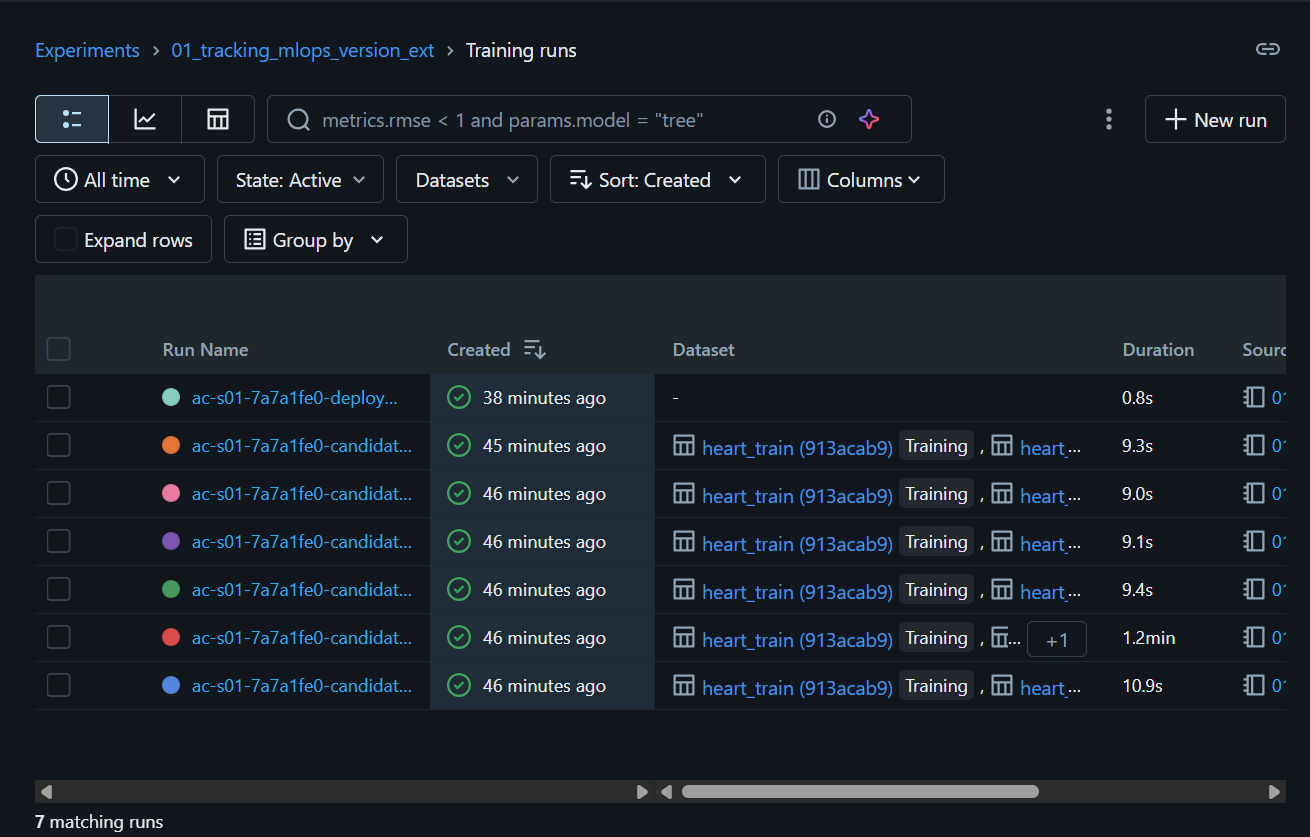

**Run ganador: métricas de test y tags**

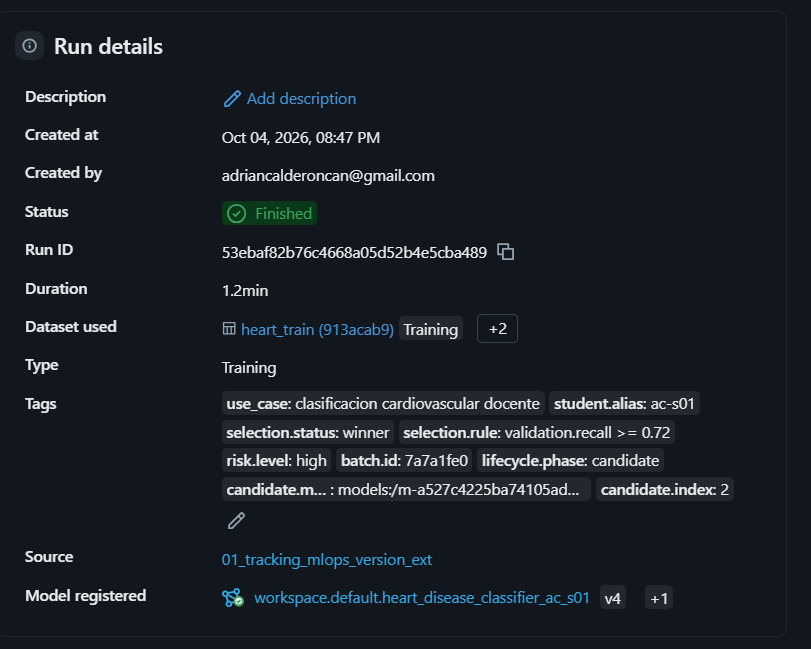

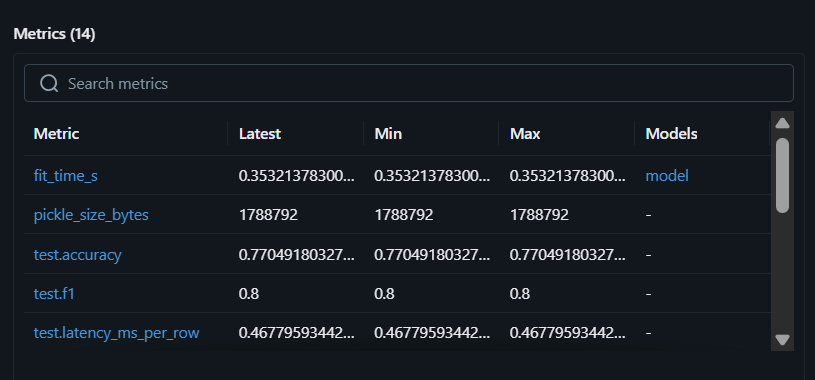

**Artefactos del ganador**

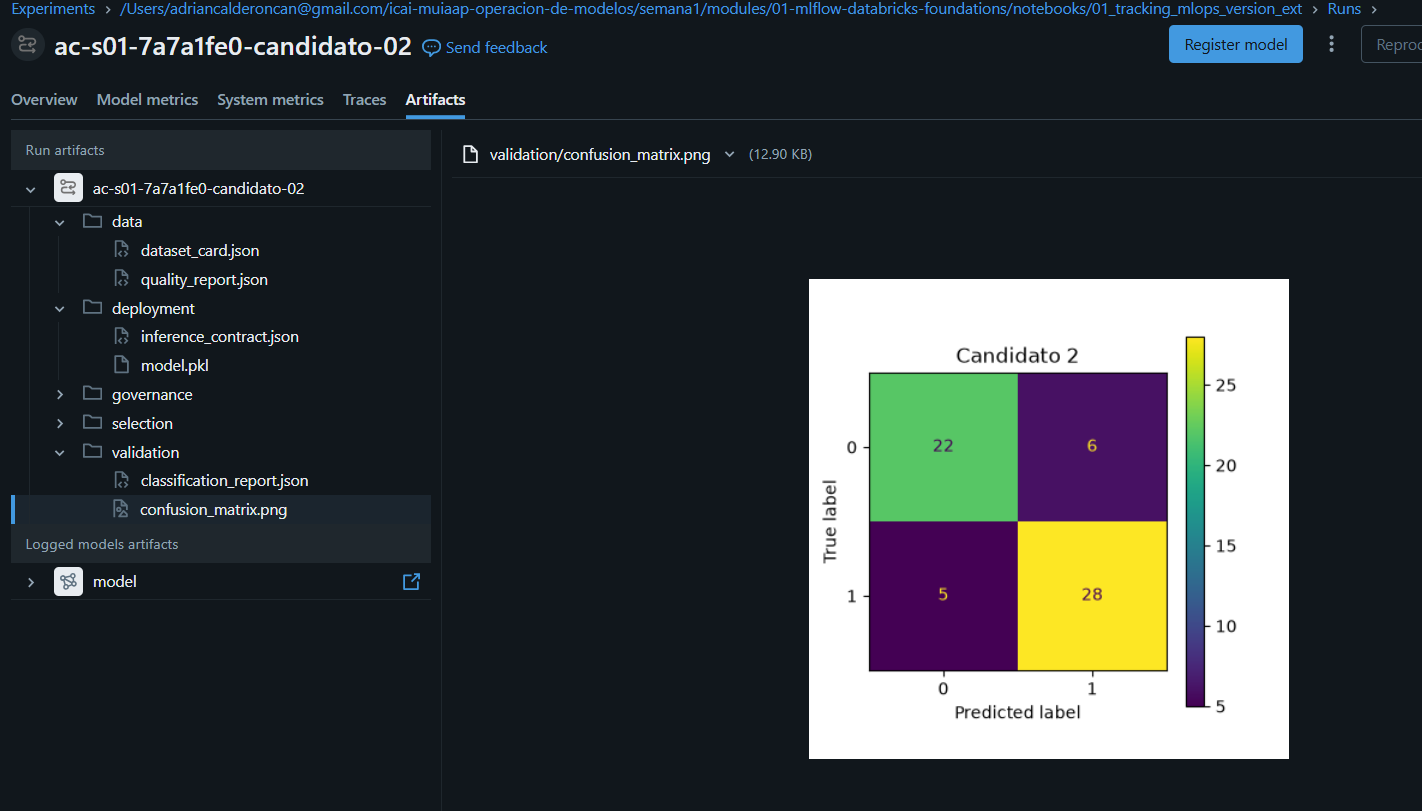

**Modelo en Unity Catalog (Champion = v4)**

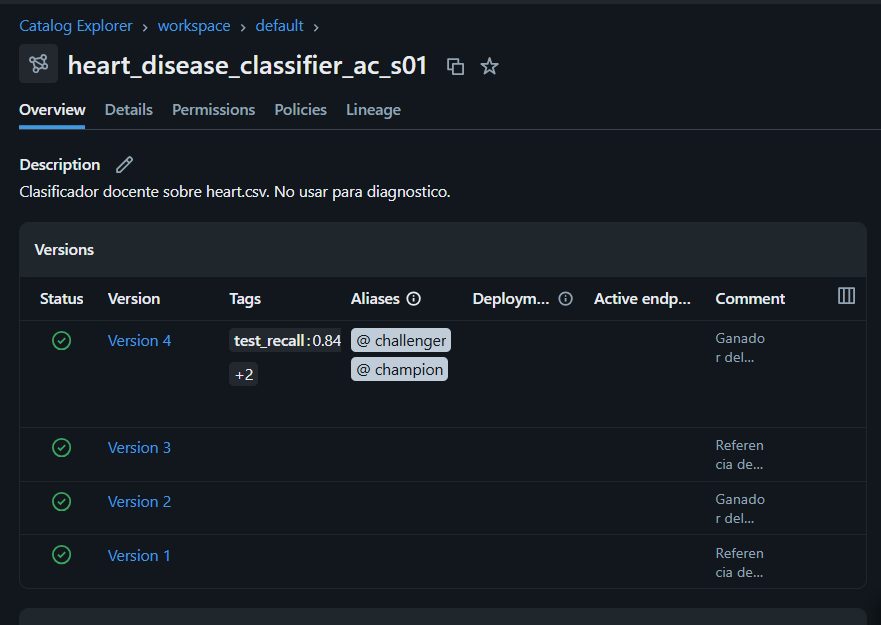

**Run de deployment**

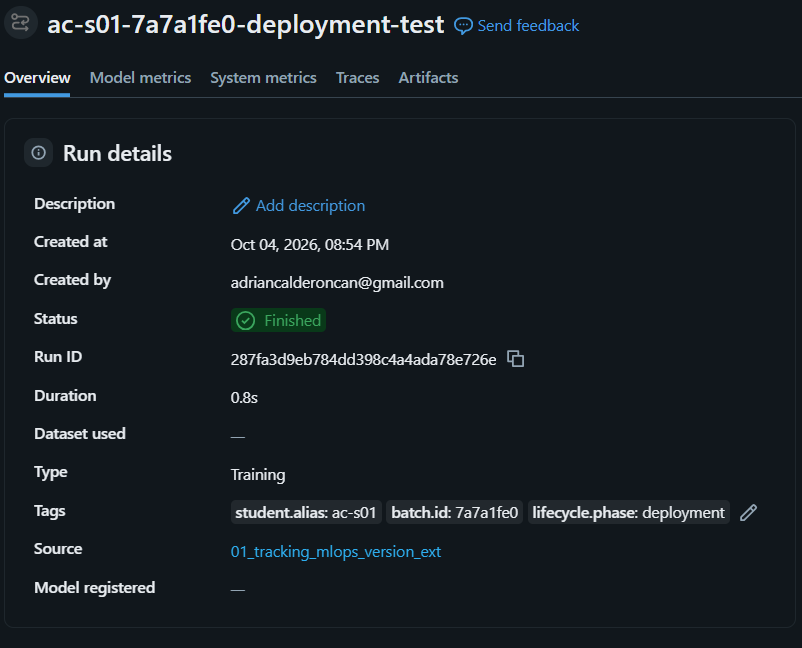